# LOAD

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r"C:\Users\Ankit_\Downloads\Datasets\Titanic Ml\train.csv")

# UNDERSTAND

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.shape

(891, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

# CLEAN

In [9]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [11]:
df.corr(numeric_only=True)["Survived"].sort_values(ascending=False)

Survived       1.000000
Fare           0.257307
Parch          0.081629
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.077221
Pclass        -0.338481
Name: Survived, dtype: float64

In [12]:
df.drop(["Cabin","PassengerId","Name","Ticket"],axis=1,inplace=True)


In [13]:
df.drop(["SibSp","Parch"],axis=1,inplace=True)

In [14]:
df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked
0,0,3,male,22.0,7.2500,S
1,1,1,female,38.0,71.2833,C
2,1,3,female,26.0,7.9250,S
3,1,1,female,35.0,53.1000,S
4,0,3,male,35.0,8.0500,S


In [15]:
df["Embarked"].value_counts()

S    644
C    168
Q     77
Name: Embarked, dtype: int64

In [16]:
#Categorical sex,embarked ==== Numerical 1,0

df = pd.get_dummies(df,columns=['Sex','Embarked'],drop_first=True)

In [17]:
df.head()

,Survived,Pclass,Age,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,7.2500,1,0,1
1,1,1,38.0,71.2833,0,0,0
2,1,3,26.0,7.9250,0,0,1
3,1,1,35.0,53.1000,0,0,1
4,0,3,35.0,8.0500,1,0,1


In [18]:
df["Age"].skew()

0.38910778230082704

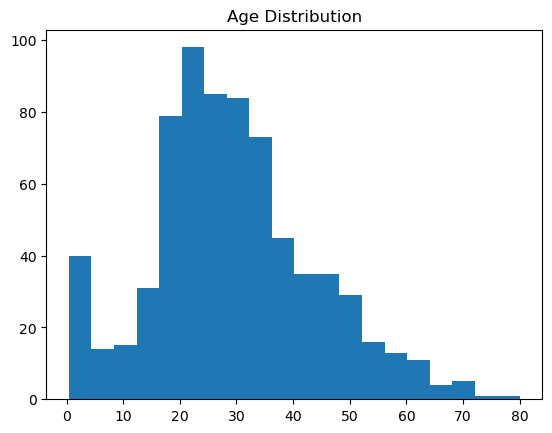

In [19]:
import matplotlib.pyplot as plt

plt.hist(df["Age"], bins=20)
plt.title("Age Distribution")
plt.show()

In [20]:
df["Age"].fillna(df["Age"].median(),inplace=True)

In [22]:
df.isnull().sum()

Survived      0
Pclass        0
Age           0
Fare          0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64

# ANALYZE ,  #VISUALIZE

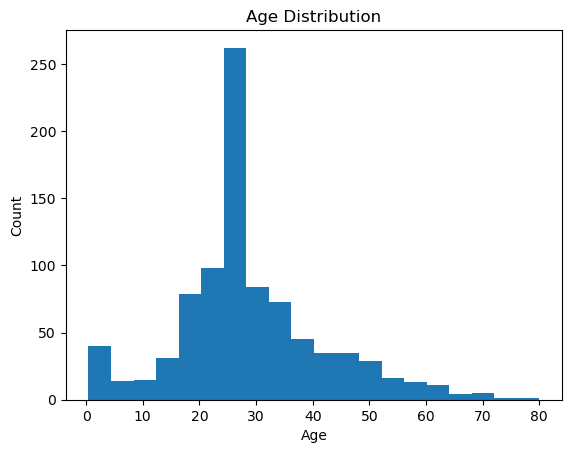

In [23]:
import matplotlib.pyplot as plt

plt.hist(df["Age"],bins=20)
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution")
plt.show()

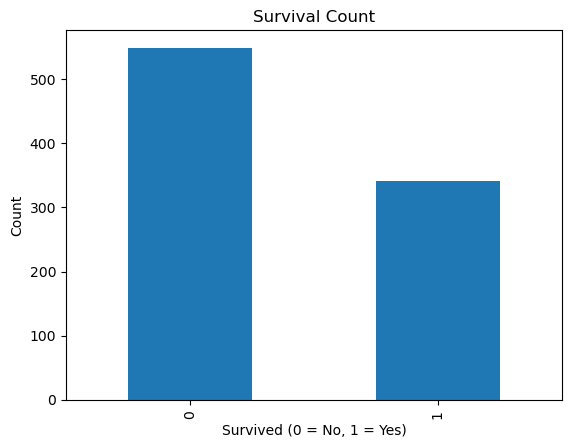

In [24]:
df["Survived"].value_counts().plot(kind="bar")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.title("Survival Count")
plt.show()

In [25]:
df.groupby("Sex_male")["Survived"].mean()

Sex_male
0    0.742038
1    0.188908
Name: Survived, dtype: float64

<Axes: xlabel='Sex_male', ylabel='count'>

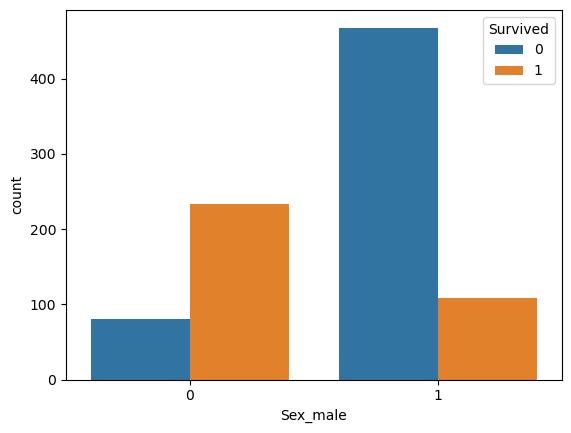

In [34]:
import seaborn as sns

sns.countplot(x="Sex_male", hue="Survived", data=df)

In [26]:
# Survival by class
df.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [27]:
# Age vs survival
df.groupby("Age")["Survived"].mean()

Age
0.42     1.0
0.67     1.0
0.75     1.0
0.83     1.0
0.92     1.0
        ... 
70.00    0.0
70.50    0.0
71.00    0.0
74.00    0.0
80.00    1.0
Name: Survived, Length: 88, dtype: float64

In [28]:
# Upgraded 
df["Age_group"] = pd.cut(df["Age"], bins=[0,10,20,30,40,50,60,80])

df.groupby("Age_group")["Survived"].mean()

Age_group
(0, 10]     0.593750
(10, 20]    0.382609
(20, 30]    0.334152
(30, 40]    0.445161
(40, 50]    0.383721
(50, 60]    0.404762
(60, 80]    0.227273
Name: Survived, dtype: float64

# INSIGHTS

✅ Insight 1:

Females have a significantly higher survival rate compared to males.

- 0 F    0.742038
- 1 M  0.188908

✅ Insight 2:

- Most passengers are in the age group of 20–40 years.

✅ Insight 3:

- Passengers who paid higher fares had a better chance of survival.
- 1    0.629630
- 2    0.472826
- 3    0.242363

<Axes: xlabel='Sex_male', ylabel='count'>

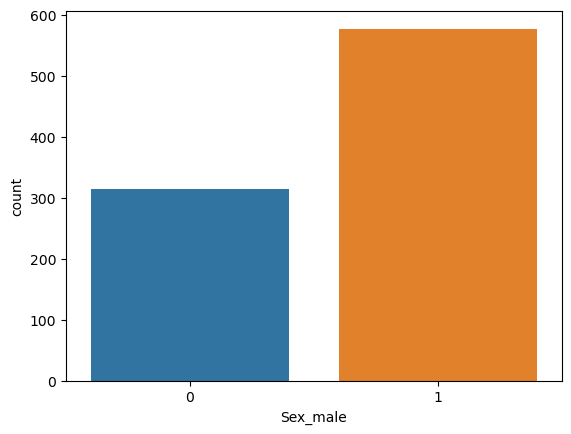

In [31]:
import seaborn as sns
sns.countplot(x="Sex_male", data=df)

In [36]:
df["Sex_male"].value_counts()

1    577
0    314
Name: Sex_male, dtype: int64